# 面板数据与固定效应教程

### 同一个个体看多次，能多知道什么

横截面数据里，每个个体只出现一次。能力、偏好、管理水平、地理位置，这些观测不到又长期不变的特征全都混在误差项里，只要它们和解释变量相关，OLS 就有偏。

面板数据对同一批个体重复观测。这带来一个横截面做不到的办法，**只比较同一个个体在不同时期的变化**。凡是不随时间变化的特征，无论观测得到还是观测不到，都在比较中抵消了。这就是固定效应。

本教程先在一份真值已知的模拟面板上把混合 OLS、固定效应、随机效应的区别演示清楚，再用美国各州的真实面板走一遍双向固定效应。全程离线。

| 节 | 内容 | 你会学到 |
| --- | --- | --- |
| 1 | 面板数据的结构 | 组间变异与组内变异 |
| 2 | 混合 OLS | 个体效应与解释变量相关时偏多少 |
| 3 | 固定效应 | 组内变换，三种等价的算法 |
| 4 | 随机效应 | 它的假设，以及它为什么介于混合 OLS 和固定效应之间 |
| 5 | 怎么选 | Hausman 检验和它的一个常见故障，Mundlak 方法 |
| 6 | 固定效应的代价 | 不随时间变化的变量估不出来 |
| 7 | 真实数据上的双向固定效应 | 州和年份固定效应分别去掉了什么 |
| 8 | 小结 | 一份清单 |

In [1]:
import warnings

warnings.filterwarnings("ignore")  # 教程里隐藏无关提示，正式分析时建议保留

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statspai as sp

plt.rcParams["figure.dpi"] = 80
pd.set_option("display.width", 120)
print("StatsPAI 版本:", sp.__version__)

StatsPAI 版本: 1.39.2


## 1. 面板数据的结构

面板模型的标准写法是

$$
y_{it} = \beta\, x_{it} + \alpha_i + \varepsilon_{it},
$$

其中 $i$ 是个体，$t$ 是时期。$\alpha_i$ 是**个体效应**，代表所有不随时间变化的个体特征的总和。$\varepsilon_{it}$ 是随时间变化的误差。

关键问题只有一个，$\alpha_i$ 与 $x_{it}$ 是否相关。

下面生成 200 个个体、6 期的面板。真实系数 $\beta = 1$。个体效应 $\alpha_i$ 同时进入 $x$ 和 $y$，所以二者相关。可以把 $\alpha_i$ 想成企业的管理水平，它使企业投入更多（$x$ 更大），也直接使产出更高。另有一个不随时间变化的可观测变量 $z$，真实系数为 0.5。

In [2]:
rng = np.random.default_rng(0)
N, T = 200, 6
BETA = 1.0

alpha = rng.normal(size=N)                       # 个体效应，观测不到
ids = np.repeat(np.arange(N), T)
periods = np.tile(np.arange(T), N)
z = rng.integers(0, 2, N)[ids]                   # 不随时间变化的可观测变量

x = 0.8 * alpha[ids] + rng.normal(size=N * T)    # x 与个体效应相关
y = BETA * x + 0.5 * z + 2.0 * alpha[ids] + rng.normal(size=N * T)

panel = pd.DataFrame({"id": ids, "t": periods, "x": x, "y": y, "z": z})
panel.head(8)

,id,t,x,y,z
0,0,0,-1.160376,-1.881570,1
1,0,1,0.933479,1.288780,1
2,0,2,1.303843,3.259055,1
3,0,3,0.737657,0.900716,1
4,0,4,0.658924,0.199782,1
5,0,5,-3.671691,-3.209021,1
6,1,0,0.154946,-0.927339,0
7,1,1,-0.131129,-1.645939,0


面板数据的变异可以拆成两部分。

- **组间变异**（between）。不同个体的平均水平之间的差别。
- **组内变异**（within）。同一个体围绕自己的平均水平的波动。

`sp.xtsum` 相当于 Stata 的 `xtsum`，把每个变量的标准差按这两部分拆开。

In [3]:
sp.xtsum(panel, ["y", "x", "z"], id="id").round(3)

mean     sd    min    max     obs
variable component                                    
y        overall    0.237  3.058 -9.191  8.180  1200.0
         between      NaN  2.797 -7.088  5.828   200.0
         within       NaN  1.250 -3.496  3.825     6.0
x        overall    0.003  1.260 -4.728  3.511  1200.0
         between      NaN  0.889 -2.633  1.905   200.0
         within       NaN  0.896 -3.643  2.684     6.0
z        overall    0.510  0.500  0.000  1.000  1200.0
         between      NaN  0.501  0.000  1.000   200.0
         within       NaN  0.000  0.510  0.510     6.0

`x` 的组间和组内标准差差不多大。`z` 的组内标准差为 0，它在同一个体内完全不变。这一点在第 6 节会变得很重要。

固定效应只使用组内变异。一个变量的组内变异越小，固定效应估计它的系数就越不精确。动手之前先看这张表是个好习惯。

## 2. 混合 OLS

最简单的做法是无视面板结构，把 1,200 个观测当作独立的横截面来回归。这叫混合 OLS（pooled OLS）。

In [4]:
pooled = sp.panel(panel, "y ~ x", entity="id", time="t", method="pooled")
print(f"混合 OLS: x 的系数 = {pooled.params['x']:.3f}  (se {pooled.std_errors['x']:.3f})    真值 {BETA}")

混合 OLS: x 的系数 = 1.929  (se 0.043)    真值 1.0


估计值接近真值的两倍。$\alpha_i$ 留在误差项里，又与 $x$ 正相关，它对 $y$ 的作用被错误地算到了 $x$ 头上。这是遗漏变量偏差，样本再大也不会消失。

下面的图把问题画了出来。取 6 个个体，每个个体用一种颜色。

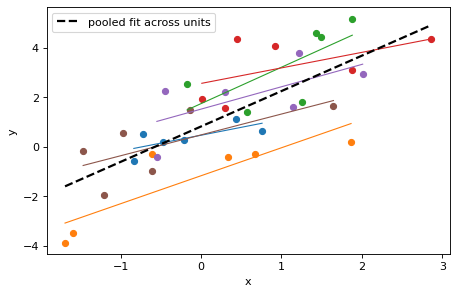

In [5]:
show = panel[panel["id"].isin([3, 17, 42, 77, 120, 151])]

fig, ax = plt.subplots(figsize=(6.5, 4))
for i, grp in show.groupby("id"):
    ax.scatter(grp["x"], grp["y"], s=30)
    slope, intercept = np.polyfit(grp["x"], grp["y"], 1)
    xs = np.array([grp["x"].min(), grp["x"].max()])
    ax.plot(xs, intercept + slope * xs, lw=1)
slope, intercept = np.polyfit(show["x"], show["y"], 1)
xs = np.array([show["x"].min(), show["x"].max()])
ax.plot(xs, intercept + slope * xs, "k--", lw=2, label="pooled fit across units")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
plt.show()

每个个体自己的拟合线（彩色细线）只有 6 个点，斜率有高有低，平均在 1 附近。各条线的高度差别很大，而且 $x$ 偏大的个体整条线也偏高。黑色虚线是把所有点混在一起的拟合，它把个体之间的这种水平差异也当成了 $x$ 的作用，所以比大多数细线更陡。

## 3. 固定效应

固定效应估计量的做法是对每个个体减去它自己的时间均值。

$$
y_{it} - \bar y_i = \beta\,(x_{it} - \bar x_i) + (\varepsilon_{it} - \bar\varepsilon_i).
$$

$\alpha_i$ 不随时间变化，它的均值就是它自己，相减之后消失了。这一步叫**组内变换**（within transformation）。变换之后对去均值的数据做 OLS 即可。

这个推导不需要对 $\alpha_i$ 和 $x$ 的关系做任何假设。无论它们怎样相关，$\alpha_i$ 都被消掉了。

In [6]:
fe = sp.panel(panel, "y ~ x", entity="id", time="t", method="fe")
print(fe.summary())

Model: Panel FE (Within)
Method: fe
Dependent Variable: y
   Coefficient  Std. Error  t-statistic  P>|t|  [0.025  0.975]
x       0.9490      0.0324      29.3148 0.0000  0.8855  1.0125

Model Diagnostics:
--------------------
R-squared           : 0.4624
R-squared (within)  : 0.4624
R-squared (between) : 0.4669
N entities          : 200.0000
N time periods      : 6.0000
F-statistic         : 859.3603
F p-value           : 0.0000


固定效应的估计值回到了真值 1 附近。

### 三种等价的算法

同一个估计量有三种算法，系数完全相同。

1. **组内变换**。手工对每个个体去均值，再做 OLS。
2. **虚拟变量法**（LSDV）。给每个个体加一个虚拟变量。
3. **一阶差分**。用 $y_{it} - y_{i,t-1}$ 对 $x_{it} - x_{i,t-1}$ 回归。只有两期时与前两种相同，多于两期时系数略有不同，但同样消掉了 $\alpha_i$。

In [7]:
# 1. 手工去均值
demeaned = panel.copy()
for col in ("x", "y"):
    demeaned[col] = panel[col] - panel.groupby("id")[col].transform("mean")
within_manual = sp.regress("y ~ x - 1", data=demeaned)

# 2. 每个个体一个虚拟变量
lsdv = sp.regress("y ~ x + C(id)", data=panel)

# 3. 一阶差分
fd = sp.panel(panel, "y ~ x", entity="id", time="t", method="fd")

pd.Series({
    "sp.panel(method='fe')": fe.params["x"],
    "manual demeaning + OLS": within_manual.params["x"],
    "unit dummies (LSDV)": lsdv.params["x"],
    "first differences": fd.params["x"],
}, name="coefficient on x").round(6)

sp.panel(method='fe')     0.949019
manual demeaning + OLS    0.949019
unit dummies (LSDV)       0.949019
first differences         0.936240
Name: coefficient on x, dtype: float64

前三行逐位相同。实际工作中不要用手工去均值的那个回归的标准误，它没有扣除估计 200 个个体均值用掉的自由度。虚拟变量法的标准误是对的，但个体数很多时既慢又占内存。`sp.panel` 和 `sp.hdfe_ols` 用组内变换计算，并自动做自由度修正。

面板数据的同一个体在不同时期的误差通常相关，所以标准误应该按个体聚类。

In [8]:
fe_cl = sp.panel(panel, "y ~ x", entity="id", time="t", method="fe", cluster="id")
print(f"固定效应，按个体聚类: x 的系数 = {fe_cl.params['x']:.3f}  (se {fe_cl.std_errors['x']:.3f})")

固定效应，按个体聚类: x 的系数 = 0.949  (se 0.030)


## 4. 随机效应

随机效应模型把 $\alpha_i$ 当作误差项的一部分，并且**假设它与 $x$ 不相关**。

$$
E[\alpha_i \mid x_{i1}, \dots, x_{iT}] = 0 .
$$

在这个假设下，混合 OLS 本身就是一致的，只是没有利用误差结构的信息。随机效应用广义最小二乘（GLS）给组内和组间变异加上最优的权重，比混合 OLS 和固定效应都更有效率。

它等价于一个「部分去均值」的回归，每个变量减去自己个体均值的 $\theta$ 倍。$\theta = 0$ 就是混合 OLS，$\theta = 1$ 就是固定效应。随机效应的 $\theta$ 在二者之间，由方差分量决定。

In [9]:
re = sp.panel(panel, "y ~ x", entity="id", time="t", method="re")

pd.DataFrame({
    "coefficient on x": [pooled.params["x"], re.params["x"], fe.params["x"]],
    "se": [pooled.std_errors["x"], re.std_errors["x"], fe.std_errors["x"]],
}, index=["pooled OLS", "random effects", "fixed effects"]).round(3)

,coefficient on x,se
pooled OLS,1.929,0.043
random effects,1.216,0.036
fixed effects,0.949,0.032


随机效应的估计值落在混合 OLS 和固定效应之间，仍然明显高于真值 1。这份数据里 $\alpha_i$ 与 $x$ 相关，随机效应的假设不成立，它和混合 OLS 一样有偏，只是偏得少一些。

三个估计量可以这样对照着记。

| 估计量 | 用到的变异 | 需要的假设 | 假设不成立时 |
| --- | --- | --- | --- |
| 混合 OLS | 组间 + 组内，等权 | $\alpha_i$ 与 $x$ 不相关 | 有偏 |
| 随机效应 | 组间 + 组内，最优加权 | $\alpha_i$ 与 $x$ 不相关 | 有偏 |
| 固定效应 | 只有组内 | 无需此假设 | 仍然一致 |

## 5. 怎么选

### Hausman 检验

Hausman (1978) 的想法很直接。如果随机效应的假设成立，固定效应和随机效应都一致，两者的估计值应该接近。如果假设不成立，只有固定效应一致，两者会系统性地不同。于是检验两组系数之差是否显著。

原假设是随机效应的假设成立。拒绝原假设意味着应该用固定效应。

In [10]:
h = sp.hausman_test(panel, y="y", x=["x"], id="id", time="t")
print(h["interpretation"])

chi2(1) = -297.6286 < 0: the FE-RE variance difference is not positive semi-definite, so the test is inconclusive.


检验统计量是负的，结果无法判定。这不是软件的错误，Stata 的 `hausman fe re` 在同样的数据上会给出同样的提示。

原因在于统计量的分母是两个估计量方差之差 $\text{Var}(\hat\beta_{FE}) - \text{Var}(\hat\beta_{RE})$。理论上随机效应更有效率，这个差应该为正。但两个方差是用各自模型的残差分别估计的，随机效应的假设严重不成立时，它的残差方差被夸大，差值就可能变成负数。

标准的补救是让两个方差使用同一个误差方差估计，对应 Stata 的 `sigmamore` 选项。

In [11]:
h2 = sp.hausman_test(panel, y="y", x=["x"], id="id", time="t", sigmamore=True)
print(h2["interpretation"])

chi2(1) = 355.3785, p = 0.0000. Reject H0: use Fixed Effects.


### Mundlak 方法

Mundlak (1978) 提供了一个更稳妥的替代。在随机效应模型里加入每个时变解释变量的**个体均值** $\bar x_i$。

$$
y_{it} = \beta\, x_{it} + \gamma\, \bar x_i + \alpha_i + \varepsilon_{it}.
$$

这个回归有两个好性质。$x_{it}$ 的系数**恰好等于固定效应估计值**。$\gamma$ 是否为 0 就是对随机效应假设的检验，它是一个普通的 Wald 检验，不会出现负的统计量，还可以配合聚类稳健的标准误。

In [12]:
mundlak = sp.panel(panel, "y ~ x", entity="id", time="t", method="mundlak")
print(mundlak.summary())

Model: Mundlak CRE
Method: mundlak
Dependent Variable: y
         Coefficient  Std. Error  t-statistic  P>|t|  [0.025  0.975]
const         0.2270      0.0727       3.1244 0.0018  0.0844  0.3695
x             0.9490      0.0324      29.3148 0.0000  0.8855  1.0125
_mean_x       1.9802      0.0881      22.4686 0.0000  1.8072  2.1531

Model Diagnostics:
--------------------
R-squared           : 0.6409
R-squared (within)  : 0.4624
R-squared (between) : 0.8658
N entities          : 200.0000
N time periods      : 6.0000
F-statistic         : 1068.1894
F p-value           : 0.0000
Mundlak terms       : 1
CRE Wald chi2       : 504.8389
CRE Wald df         : 1
CRE Wald p-value    : 0.0000
CRE interpretation  : Reject H0: use FE

`x` 的系数与第 3 节的固定效应估计值完全相同。`_mean_x` 的系数显著不为 0，Wald 检验拒绝了随机效应的假设。

**实用建议**。因果推断的应用里几乎总是用固定效应，因为「个体效应与解释变量不相关」很少站得住。随机效应更多用在多层模型和预测问题里。如果要做检验，优先用 Mundlak 形式。

## 6. 固定效应的代价

固定效应不是免费的。

**不随时间变化的变量估不出来**。组内变换把 $\alpha_i$ 消掉的同时，也把所有不随时间变化的解释变量消掉了。数据里的 $z$ 就是这样一个变量。

In [13]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    fe_z = sp.panel(panel, "y ~ x + z", entity="id", time="t", method="fe")

print("固定效应的系数:", fe_z.params.round(3).to_dict())
print("提示:", caught[0].message)

固定效应的系数: {'x': 0.949}
提示: sp.panel(method='fe'): ['z'] omitted because the fixed effects absorb them (no variation left within units, or collinear with the other regressors).


`z` 被自动剔除，并给出了说明。性别、出生地、行业这类变量在个体固定效应模型里都估不出来。

Mundlak 回归可以把它们留下，同时 `x` 的系数仍然是固定效应估计值。不过 `z` 的系数要可信，需要 `z` 本身与个体效应不相关，这是一个额外的假设。

In [14]:
mundlak_z = sp.panel(panel, "y ~ x + z", entity="id", time="t", method="mundlak")
print(mundlak_z.params.round(3).to_string())
print("\nz 的真实系数为 0.5")

const     -0.070
x          0.949
z          0.583
_mean_x    1.999

z 的真实系数为 0.5


固定效应还有另外两个代价，使用时要心里有数。

- **精度下降**。丢掉组间变异之后，可用的信息变少了，标准误通常变大。组内变异很小的变量尤其如此。
- **测量误差被放大**。解释变量的测量误差在去均值之后占的比重更大，衰减偏差更严重。

它也只能处理**不随时间变化**的混淆因素。随时间变化的不可观测因素仍然会造成偏差，固定效应帮不上忙。

## 7. 真实数据上的双向固定效应

`sp.datasets.castle_doctrine()` 是 Cheng and Hoekstra (2013) 的数据。50 个州，2000 到 2010 年，共 550 个观测。2005 到 2009 年间有 21 个州扩大了「城堡法」的适用范围（遭遇威胁时没有退让义务，可以直接使用致命武力），其余 29 个州没有。研究问题是这类法律对凶杀率的影响。

| 变量 | 含义 |
| --- | --- |
| `state`, `year` | 州，年份 |
| `l_homicide` | 每十万人凶杀数的对数 |
| `post` | 该州当年是否已实施扩大后的城堡法 |
| `cdl` | 同上，但实施当年按生效月份折算成 0 到 1 之间的比例 |
| `popwt` | 州人口，用作权重 |

In [15]:
castle = sp.datasets.castle_doctrine()
print(castle.shape, "|", castle["state"].nunique(), "个州 |", int(castle["year"].min()), "到", int(castle["year"].max()))
sp.xtsum(castle, ["l_homicide", "post"], id="state").round(3)

(550, 29) | 50 个州 | 2000 到 2010


mean     sd    min    max    obs
variable   component                                   
l_homicide overall    1.406  0.590 -0.436  2.676  550.0
           between      NaN  0.566  0.153  2.527   50.0
           within       NaN  0.185  0.554  2.130   11.0
post       overall    0.135  0.342  0.000  1.000  550.0
           between      NaN  0.169  0.000  0.455   50.0
           within       NaN  0.298 -0.320  1.044   11.0

凶杀率的组间标准差远大于组内标准差。各州之间的长期差别很大，同一个州在十年里的波动相对小。直接比较实施和未实施的州，比较的主要是前者。

下面依次加入州固定效应和年份固定效应。`sp.hdfe_ols` 用竖线分隔回归方程和要吸收的固定效应，相当于 Stata 的 `reghdfe`。标准误按州聚类。

In [16]:
m_pooled = sp.regress("l_homicide ~ post", data=castle, cluster="state")
m_state = sp.hdfe_ols("l_homicide ~ post | state", data=castle, cluster="state")
m_year = sp.hdfe_ols("l_homicide ~ post | year", data=castle, cluster="state")
m_twoway = sp.hdfe_ols("l_homicide ~ post | state + year", data=castle, cluster="state")

pd.DataFrame({
    "coefficient on post": [m.params["post"] for m in (m_pooled, m_state, m_year, m_twoway)],
    "se (clustered by state)": [m.std_errors["post"] for m in (m_pooled, m_state, m_year, m_twoway)],
}, index=["pooled OLS", "state FE", "year FE", "state + year FE"]).round(4)

,coefficient on post,se (clustered by state)
pooled OLS,0.3380,0.0925
state FE,-0.0079,0.0485
year FE,0.5178,0.1280
state + year FE,0.0694,0.0559


四个设定给出的答案差别很大，每一步的变化都有明确的含义。

- **混合 OLS** 的系数很大。它比较的是实施了城堡法的州年与其他所有州年。实施这类法律的州有一半以上在南方，它们在实施之前凶杀率就明显更高。这个系数主要反映的是州与州之间的长期差别。
- **加入州固定效应**之后系数接近 0。现在比较的是同一个州实施前后的变化。但 2008 年之后全国的平均凶杀率明显下降，而多数州的「实施之后」恰好落在这几年，这个全国性的变化被算进了法律的效应。
- **只加年份固定效应**去掉了全国性的年度冲击，但州之间的长期差别还在，系数又回到了很大的值。
- **双向固定效应**同时去掉这两类混淆。剩下的是「实施州相对于自身的变化」减去「同一年未实施州的变化」。这就是双重差分的回归形式。

原论文使用人口加权，处理变量用按月份折算的 `cdl`。

In [17]:
m_paper = sp.hdfe_ols(
    "l_homicide ~ cdl | state + year", data=castle, weights="popwt", cluster="state"
)
print(f"人口加权的双向固定效应: cdl 的系数 = {m_paper.params['cdl']:.4f}  (se {m_paper.std_errors['cdl']:.4f},  p = {m_paper.pvalues['cdl']:.3f})")

人口加权的双向固定效应: cdl 的系数 = 0.0801  (se 0.0342,  p = 0.023)


人口加权之后，估计值约为 0.08，即扩大城堡法使凶杀率上升约 8%，在 5% 水平上显著。法律的支持者预期它能威慑犯罪，数据显示的方向相反。

读这个结果时有三点需要注意。

- **双向固定效应依赖平行趋势假设**。没有这项法律时，实施州和未实施州的凶杀率应该有相同的变化趋势。固定效应去不掉随时间变化的州特有冲击。
- **各州实施的年份不同**，这是交错处理。处理效应如果随时间变化，双向固定效应的系数可能有偏。`tutorial_did_staggered.ipynb` 专门讨论这个问题。
- **加权改变了估计的对象**。不加权时每个州同等重要，人口加权后大州的权重更大，回答的是「对一个普通居民的影响」。两种都合理，但要说明用的是哪一种。上面不加权的 `post` 系数是 0.07，标准误也更大。

`sp.hdfe_ols` 可以吸收任意多组固定效应，写法是 `y ~ x | fe1 + fe2 + fe3`。个体数达到百万级时仍然很快。

## 8. 小结

1. **先看变异的来源**（`sp.xtsum`）。固定效应只用组内变异，组内变异太小的变量估不准。
2. **个体效应与解释变量相关时，混合 OLS 和随机效应都有偏**。因果问题默认用固定效应。
3. **固定效应消掉所有不随时间变化的混淆因素**，无论是否观测得到。它消不掉随时间变化的混淆因素。
4. **不随时间变化的变量在固定效应模型里估不出来**。需要它们的系数时考虑 Mundlak 回归，并说明额外的假设。
5. **检验随机效应的假设时优先用 Mundlak 形式**。经典 Hausman 统计量可能为负。
6. **标准误按个体聚类**。固定效应不能代替聚类。
7. **双向固定效应就是 DID 的回归形式**。它依赖平行趋势，处理时点交错时还要小心异质性效应。

| 任务 | 函数 |
| --- | --- |
| 组间与组内变异 | `sp.xtsum` |
| 混合 OLS、固定效应、随机效应、一阶差分、Mundlak | `sp.panel(..., method=...)` |
| Hausman 检验 | `sp.hausman_test` |
| 多组高维固定效应 | `sp.hdfe_ols("y ~ x \| fe1 + fe2")` |

延伸阅读见 `docs/guides/panel_data.md`。

### 本教程用到的方法的文献

下面的 BibTeX 条目直接取自 StatsPAI 核验过的 `paper.bib`。

In [18]:
keys = [
    "mundlak1978pooling",
    "hausman1978specification",
    "wooldridge2010econometric",
    "cheng2013does",
]
print(sp.bibtex(keys))

@article{mundlak1978pooling,
  title={On the Pooling of Time Series and Cross Section Data},
  author={Mundlak, Yair},
  journal={Econometrica},
  year={1978},
  doi={10.2307/1913646}
}

@article{hausman1978specification,
  title={Specification Tests in Econometrics},
  author={Hausman, J. A.},
  journal={Econometrica},
  year={1978},
  doi={10.2307/1913827}
}

@book{wooldridge2010econometric,
  title={Econometric Analysis of Cross Section and Panel Data},
  author={Wooldridge, Jeffrey M.},
  publisher={MIT Press},
  edition={2nd},
  year={2010},
  isbn={978-0-262-23258-6},
  annote={No DOI: MIT Press has not registered this book with Crossref (searched by title and author, 2026-08-24). Cite by ISBN.}
}

@article{cheng2013does,
  title={Does Strengthening Self-Defense Law Deter Crime or Escalate Violence?: Evidence from Expansions to Castle Doctrine},
  author={Cheng, Cheng and Hoekstra, Mark},
  journal={Journal of Human Resources},
  volume={48},
  number={3},
  pages={821--853},
  y